# Flood Data Prep

In [6]:
import os
import glob
import json
from datetime import datetime, timedelta
import re

import numpy as np
import geopandas as gpd
from shapely.geometry import box

import xarray as xr

import matplotlib.pyplot as plt

import rasterio
from rasterio.mask import mask
from rasterio.merge import merge
from rasterio.warp import reproject, Resampling
from rasterio.io import MemoryFile

from sklearn.preprocessing import StandardScaler, MinMaxScaler

import warnings
from scipy.ndimage import uniform_filter

warnings.filterwarnings('ignore')

In [7]:
import sys
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

## Load Base Data 

Loads a GeoTIFF and crops it to the exact shape of a GeoJSON boundary obtained from GAUL

In [8]:
def load_and_crop_data(tif_path, geojson_path): 
    with rasterio.open(tif_path) as src:
        boundary_gdf = gpd.read_file(geojson_path).dropna(subset=['geometry'])
        boundary_gdf = boundary_gdf[~boundary_gdf.geometry.is_empty]

        if boundary_gdf.empty or not boundary_gdf.crs:
            raise ValueError(f"Invalid or empty boundary: {geojson_path}")

        if boundary_gdf.crs != src.crs:
            boundary_gdf = boundary_gdf.to_crs(src.crs)

        # Filter to only polygons that explicitly overlap the raster
        raster_bounds_geom = box(*src.bounds)
        overlapping_geoms = boundary_gdf[boundary_gdf.intersects(raster_bounds_geom)]

        if overlapping_geoms.empty:
            raise ValueError("No spatial overlap between boundary and raster.")

        # Apply a microscopic buffer to bypass GDAL floating point math bugs
        safe_geometries = overlapping_geoms.geometry.buffer(0.0001)

        try:
            # Mask the raster, using all_touched=True to be more permissive at the edges
            out_image, out_transform = mask(
                src, 
                safe_geometries, 
                crop=True, 
                filled=True,
                all_touched=True 
            )
        except ValueError as e:
            if "do not overlap" in str(e):
                # If GDAL complains, read it as is
                print("  [INFO] Skipping mask")
                out_image = src.read()
                out_transform = src.transform
            else:
                raise e

        # Safely cast to float32 and inject NaNs
        out_image_float = out_image.astype(np.float32)
        native_nodata = src.nodata if src.nodata is not None else 0
        out_image_float[out_image_float == native_nodata] = np.nan

        profile = src.profile
        profile.update({
            "height": out_image_float.shape[1],
            "width": out_image_float.shape[2],
            "transform": out_transform,
            "nodata": np.nan,
            "dtype": "float32"
        })

    return out_image_float, profile

## Align

Forces all disparate geospatial datasets to share the exact same pixel grid, dimensions, and Coordinate Reference System (CRS) as our master S1 imagery

In [9]:
def align_and_process_raster(source_path, master_profile, data_type):

    # the target dimensions based on the master grid (S1)
    dst_h = master_profile["height"]
    dst_w = master_profile["width"]

    with rasterio.open(source_path) as src:
        aligned_array = np.full((src.count, dst_h, dst_w), np.nan, dtype=np.float32)
        for band_idx in range(1, src.count + 1):
            src_band = src.read(band_idx).astype(np.float32)
            dst_band = np.full((dst_h, dst_w), np.nan, dtype=np.float32)

            # Resampling Algorithm
            # Nearest neighbor for 'env' to protect categorical landcover classes
            # grabs the exact value of the single closest pixel without averaging
            # Bilinear Interpolation calculates a weighted average of the 4 nearest pixels
            # creates smooth transitions and is perfect for continuous data like rainfall or radar backscatter  
            if data_type == "gfm":
                resampling_algo = Resampling.nearest
            elif data_type == "env":
                if band_idx == 5: # In the ENV stack, Band 5 (index 4) is categorical Landcover
                    resampling_algo = Resampling.nearest
                else: # Bands 1-4 (DEM, Slope, HAND) are continuous topography
                    resampling_algo = Resampling.bilinear
            else:# Default to bilinear for continuous data (weather, S1, hydro, etc.)
                resampling_algo = Resampling.bilinear

            reproject( # reproject the source band pixels to the master grid 
                source=src_band,
                destination=dst_band,
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=master_profile["transform"],
                dst_crs=master_profile["crs"],
                src_nodata=src.nodata,
                dst_nodata=np.nan,
                resampling=resampling_algo,
            )
            aligned_array[band_idx - 1] = dst_band #(0-indexed array vs 1-indexed rasterio bands)

    # Handle NoData / outliers 
    aligned_array[aligned_array < -9000] = np.nan

    return aligned_array

## Global Stats

Calculates the 1st and 99th percentiles for continuous feature bands across a representative sample of the dataset, saving the results to a JSON file

In [10]:
def calculate_and_save_global_stats(base_dir, output_json_path, num_file_samples=10):

    modalities = {
        "env": {
            "folder": "ENV",
            "no_data_thresh": -100, # Ignore extreme negative elevations (noise)
            "skip_bands": [4]       # Skip index 4 (Categorical Landcover)
        },
        "weather": {
            "folder": "WEATHER",
            "no_data_thresh": None,
            "skip_bands": []
        },
        "hydro": {
            "folder": "HYDRO",
            "no_data_thresh": None,
            "skip_bands": []
        }
    }
    
    global_stats = {"env": {}, "weather": {}, "hydro": {}}
    
    # Iterate through each modality to gather pixel data
    for mod_name, config in modalities.items():
        search_path = os.path.join(base_dir, config["folder"], "*.tif")
        all_files = glob.glob(search_path)
        
        if not all_files:
            continue
            
        # Subsample files to save memory and time
        if len(all_files) > num_file_samples:
            np.random.seed(42) 
            sampled_files = np.random.choice(all_files, num_file_samples, replace=False)
        else:
            sampled_files = all_files
            
        temp_band_data = {}
        
        # Read pixels from the sampled files
        for file_path in sampled_files:
            with rasterio.open(file_path) as src:
                for band_idx in range(src.count):
                    if band_idx in config["skip_bands"]:
                        continue
                        
                    if band_idx not in temp_band_data:
                        temp_band_data[band_idx] = []
                        
                    band_pixels = src.read(band_idx + 1).astype(np.float32)
                    
                    # Apply specific no-data thresholds
                    if config["no_data_thresh"] is not None:
                        band_pixels[band_pixels < config["no_data_thresh"]] = np.nan
                        
                    valid_pixels = band_pixels[~np.isnan(band_pixels)]
                    
                    # Subsample pixels if the array is massive (extract 100k random pixels per band per file)
                    if len(valid_pixels) > 100000:
                        valid_pixels = np.random.choice(valid_pixels, 100000, replace=False)
                        
                    temp_band_data[band_idx].extend(valid_pixels)
        
        # Calculate the 1st and 99th percentiles for each band
        for band_idx, pixels in temp_band_data.items():
            if not pixels:
                continue
                
            pixel_array = np.array(pixels)
            global_stats[mod_name][band_idx] = {
                "min": float(np.percentile(pixel_array, 1)),
                "max": float(np.percentile(pixel_array, 99)),
                "mean": float(np.mean(pixel_array))
            }
            
    # Save the calculated statistics to a JSON file for quick loading later
    output_json_path = os.path.join(base_dir, output_json_path)
    with open(output_json_path, "w") as f:
        json.dump(global_stats, f, indent=4)
        
    return global_stats

## Sanitize & Normalize

Removes sensor noise and scales continuous variables to [0, 1] using global percentiles or physical limits

In [11]:
WORLDCOVER_CLASSES = [10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 100]

TODO: Z scoring features like HAND

In [12]:
def sanitize_and_normalize(image, data_type, global_stats=None):
    # to avoid modifying the original array in memory
    image = image.astype(np.float32, copy=True)
    num_bands = image.shape[0]

    # We will store each processed layer here and concatenate them at the end
    processed_channels = []

    # Remove known physical noise
    if data_type == "s1":
        # Radar backscatter below -50 dB is sensor noise - set to NaN
        image[image < -50] = np.nan 
    elif data_type == "env":
        # DEM (Elevation) is band 0 - Values drastically below sea level are noise
        image[0][image[0] < -100] = np.nan 
    elif data_type == "gfm":
        # The Global Flood Monitoring (GFM) mask is our target label - Convert it to pure binary (0 = No Flood, 1 = Flood)
        image = np.where(np.isnan(image), np.nan, (image > 0).astype(np.float32))
        return np.nan_to_num(image, nan=0.0)

    # Scale values to [0, 1]
    for i in range(num_bands):
        # get the band values from the image stack
        band = image[i]
        # Only scale pixels that are actual data (not NaN)
        valid_mask = ~np.isnan(band)

        # Categorical classes in Landcover (e.g., 'Urban', 'Forest') cannot be scaled as a gradient
        if data_type == "env" and i == 4:
            # Replace NaNs with a dummy background value (0) so they don't trigger a class
            lc_int = np.nan_to_num(band, nan=0).astype(np.int32)
            # Create an 11-channel binary mask stack
            ohe_stack = np.stack([(lc_int == cls).astype(np.float32) for cls in WORLDCOVER_CLASSES], axis=0)
            processed_channels.append(ohe_stack)
            continue 
        # Normalized ENV = 15 bands = 4 (Normalized Continuous Bands) + 11 (OHE Landcover)
           
        # Continuous Data
        if valid_mask.sum() > 0:
            # Radar - Water reflects signal away, resulting in low dB
            if data_type == "s1":
                # We use strict physical bounds instead of dataset stats
                # VV band limits: [-25.0, 0.0] | VH band limits: [-30.0, -5.0]
                vmin, vmax = (-25.0, 0.0) if i == 0 else (-30.0, -5.0)
                scaled_band = (band[valid_mask] - vmin) / (vmax - vmin)
                band[valid_mask] = np.clip(scaled_band, 0.0, 1.0)


            # Weather (Using strict physical bounds instead of random stats)
            elif data_type == "weather":
                if i in [0, 1, 2]:    # Precip 1D, 3D, 7D (mm)
                    vmax = 200.0      # Assume 200mm is an extreme max
                    scaled_band = band[valid_mask] / vmax
                elif i == 3:          # Soil Moisture (fraction or mm)
                    vmax = 1.0        # Usually 0 to 1, or adjust if your unit is different
                    scaled_band = band[valid_mask] / vmax
                elif i == 4:          # Temperature (Assuming Kelvin)
                    vmin, vmax = 250.0, 315.0 
                    scaled_band = (band[valid_mask] - vmin) / (vmax - vmin)
                elif i == 5:          # Evaporation
                    vmax = 10.0
                    scaled_band = band[valid_mask] / vmax
                else:
                    scaled_band = band[valid_mask] # Fallback
                    
                band[valid_mask] = np.clip(scaled_band, 0.0, 1.0)
                
            elif data_type == "glofas":
                vmax = 2500.0 # Empirically cap river discharge spike at 2500 m^3/s
                scaled_band = band[valid_mask] / vmax
                band[valid_mask] = np.clip(scaled_band, 0.0, 1.0)

            elif data_type in ["env", "hydro"]:
                # For continuous data (Elevation, Rain), use the 1st/99th percentiles from global_stats
                g_min = global_stats[data_type][i]["min"]
                g_max = global_stats[data_type][i]["max"]
                if g_max > g_min:
                    scaled_band = (band[valid_mask] - g_min) / (g_max - g_min)
                    band[valid_mask] = np.clip(scaled_band, 0.0, 1.0)
                else:
                    band[valid_mask] = 0.0
            else:
                # Fallback for glofas/hydro if they aren't caught above
                # (Assuming they don't need scaling, or are already 0-1)
                pass
            # Fill NaNs with 0.0
            band[~valid_mask] = 0.0
            # Keep 3D shape (1, H, W) for concatenation
            processed_channels.append(band[np.newaxis, :, :])
            # # Put the processed band back into the image stack
            # image[i] = band

    # image = np.nan_to_num(image, nan=0.0)
    # Stack everything along the channel axis (axis=0)
    # Env stack becomes: 4 continuous bands + 11 OHE bands = 15 channels total
    final_tensor = np.concatenate(processed_channels, axis=0)
    
    return final_tensor

## Dates (align s1 and gfm dates)

Scans directories to find intersecting dates between a master dataset (e.g. S1) and a target dataset (e.g. GFM)

In [13]:
def inventory_dataset_dates(base_dir, region, master_profile_dir="S1", master_profile_str="S1"):

    search_path = os.path.join(base_dir, master_profile_dir, "*.tif")
    s1_files = glob.glob(search_path)

    master_pattern = rf'{master_profile_str}_(\d{{4}}-\d{{2}}-\d{{2}})\.tif$'

    # Extract all valid S1 dates
    s1_dates = {
        re.search(master_pattern, f).group(1) 
        for f in s1_files if re.search(master_pattern, f)
    }

    target_dates = sorted(list(s1_dates))
    
    print(f"Inventory for {region}: Found {len(target_dates)} master (S1) dates.")
    return target_dates

## Daily Temporal Mosaic (GFM)

Merges raw GFM tiles for a target date, aligns them to the master grid

In [14]:
def build_gfm_mosaic(date_str, gfm_dir, master_profile):
    # Format date to match GFM file naming conventions (YYYYMMDD)
    date_format = date_str.replace("-", "")
    tile_paths = glob.glob(os.path.join(gfm_dir, f"*{date_format}*.tif"))

    print(f"Building GFM mosaic for {date_str} : {len(tile_paths)} tiles")

    # if not tile_paths:
    #     raise FileNotFoundError(f"No GFM tiles found for {date_str}")
    if not tile_paths:
        print(f"  [WARN] GFM missing for {date_str}; returning empty tensor.")
        return None

    # Open all matching tiles
    src_files = [rasterio.open(fp) for fp in tile_paths]
    
    # Merge the raw tiles into a single contiguous array
    mosaic, mosaic_transform = merge(src_files)
    mosaic_crs = src_files[0].crs 
    
    # Close the source files to free up memory
    for src in src_files: 
        src.close()

    temp_tif_path = os.path.join(gfm_dir, f"temp_gfm_{date_str}.tif")
    
    with rasterio.open(
        temp_tif_path, 'w', driver='GTiff',
        height=mosaic.shape[1], width=mosaic.shape[2],
        count=1, dtype=mosaic.dtype, crs=mosaic_crs, transform=mosaic_transform
    ) as dst:
        dst.write(mosaic)

    aligned_mosaic = align_and_process_raster(temp_tif_path, master_profile, data_type="gfm")

    # Clean up the disk
    if os.path.exists(temp_tif_path):
        os.remove(temp_tif_path)

    # Return the aligned array
    return aligned_mosaic

## Daily Weather 

Loads the pre-aggregated GEE weather stack for the target date, aligns it to the master grid

In [15]:
def process_daily_weather(target_date_str, weather_dir, region, master_profile):

    weather_file = os.path.join(weather_dir, f"WEATHER_{region}_weather_1km_{target_date_str}.tif")

    print(f"Processing weather for {target_date_str} : {weather_file}")

    if not os.path.exists(weather_file):
        print(f"  [WARN] Weather missing for {target_date_str}; returning empty tensor.")
        return None

    # Align to the master grid (S1 resolution/bounds) 
    # We use Bilinear resampling inside our helper because weather (precip/temp) is continuous
    aligned_weather = align_and_process_raster(weather_file, master_profile, data_type="weather")
    
    return aligned_weather

## Daily GloFAS

Loads pre sliced GloFAS daily to the target date, aligns it to master grid

In [16]:
def process_daily_glofas(target_date_str, glofas_dir, region, master_profile):
    # Construct the exact path to the daily GeoTIFF 
    glofas_file = os.path.join(glofas_dir, f"GLOFAS_{region}_{target_date_str}.tif")

    if not os.path.exists(glofas_file):
        print(f"  [WARN] GloFAS missing for {target_date_str}; returning empty tensor.")
        return None

    #  Align to the master grid (S1 resolution/bounds) 
    aligned_glofas = align_and_process_raster(glofas_file, master_profile, data_type="glofas")
    
    return aligned_glofas

## Label from S1

Creates adaptive S1 only flood labels using Lee filtered Otsu thresholds

In [17]:
from scipy.ndimage import uniform_filter, median_filter
from skimage.filters import threshold_otsu

speckle - a granular noise that looks like salt and pepper, caused by the interference of radar waves reflecting off rough surfaces    

Lee filter is a spatial filter designed specifically to smooth out this speckle noise in homogeneous areas (like open water or flat land) while preserving sharp edges (like the boundary between a river and a riverbank)   

- The filter looks at a local moving window (7x7 pixel grid)
- calculate local mean and the local variance within that 7x7 window
- Compare the local variance to the overall image variance
- Low Variance (Homogeneous area): If the local variance is low, the filter assumes it is looking at a uniform surface and replaces the pixel with the local mean (heavy smoothing)
- High Variance (Edges/Heterogeneous): If the local variance is high, it assumes it is looking at an edge. The filter leaves the pixel closer to its original value to preserve the structural boundary

In [18]:
def apply_lee_filter(img, size=7):

    img_mean = uniform_filter(img, size=size, mode="reflect")
    img_sq_mean = uniform_filter(img ** 2, size=size, mode="reflect")
    
    # Clip to 0 to prevent floating-point negative variance
    img_var = np.clip(img_sq_mean - img_mean ** 2, 0, None)
    overall_var = np.nanvar(img)
    
    weight = img_var / (img_var + overall_var + 1e-10)
    return img_mean + weight * (img - img_mean)

water is a flat surface, radar pulses reflect away from the satellite (specular reflection), causing water to appear very dark (low backscatter in decibels, or dB) Land surfaces scatter radar pulses back toward the satellite, appearing bright    

Otsu algorithm iterates through all possible threshold values and calculates the spread (variance) of the pixel values on each side of the threshold

It selects the threshold that strictly minimizes the intra class variance (pixels within the "water" class are as similar to each other as possible) while maximizing the inter class variance (the "water" class is as different from the "land" class as possible)

In [19]:
def compute_otsu(filtered_band, valid_mask, default_thresh):

    valid_pixels = filtered_band[valid_mask]
    if len(valid_pixels) == 0:
        return default_thresh
        
    # Calculate local variance (3x3 window) to find structural boundaries
    local_mean = uniform_filter(filtered_band, size=3, mode="reflect")
    local_sq_mean = uniform_filter(filtered_band ** 2, size=3, mode="reflect")
    local_var = np.clip(local_sq_mean - local_mean ** 2, 0, None)
    
    # Extract variances for valid pixels only
    valid_vars = local_var[valid_mask]
    
    # If the scene is completely uniform (no boundaries/all land), use fallback
    if np.max(valid_vars) < 0.1: 
        return default_thresh
        
    # Select the top 10% most variable pixels (the edges between land and water)
    percentile_90 = np.percentile(valid_vars, 90)
    bimodal_pixels = valid_pixels[valid_vars >= percentile_90]
    
    try:
        return float(threshold_otsu(bimodal_pixels))
    except ValueError:
        return default_thresh

In [20]:
# def compute_otsu(valid_pixels, default_thresh):

#     if len(valid_pixels) == 0:
#         return default_thresh
#     try:
#         # skimage implementation is quite fast and heavily tested
#         return float(threshold_otsu(valid_pixels))
#     except ValueError:
#         return default_thresh

    # if values.size == 0:
    #     return np.nan

    # hist, bin_edges = np.histogram(values, bins=num_bins)
    # hist = hist.astype(np.float64)
    # centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0

    # weight1 = np.cumsum(hist)
    # weight2 = np.cumsum(hist[::-1])[::-1]

    # mean1 = np.cumsum(hist * centers) / np.maximum(weight1, 1e-12)
    # mean2 = (np.cumsum((hist * centers)[::-1]) / np.maximum(weight2[::-1], 1e-12))[::-1]

    # inter_class_var = weight1[:-1] * weight2[1:] * (mean1[:-1] - mean2[1:]) ** 2
    # if inter_class_var.size == 0:
    #     return np.nan

    # idx = int(np.nanargmax(inter_class_var))
    # return float(centers[idx])

applies the 7x7 Lee Filter, calculates Otsu thresholds for both VV and VH bands (defaulting to -17.0 dB and -23.0 dB if Otsu fails), and classifies water only if both bands fall below their respective thresholds ((vv <= t_vv) & (vh <= t_vh)) and finishes with a 3x3 median filter to clean up stray pixels

In [29]:
def build_s1_label_from_raw(s1_raw_db):
    if s1_raw_db.shape[0] < 2:
        raise ValueError("Expected two S1 bands (VV, VH) to build labels.")

    vv = s1_raw_db[0].astype(np.float32)
    vh = s1_raw_db[1].astype(np.float32)

    # Define Valid Pixels (-50dB is the typical SAR noise floor)
    valid = (~np.isnan(vv)) & (~np.isnan(vh)) & (vv > -50) & (vh > -50)

    # Fill NaNs with standard land values to avoid breaking the spatial filters
    vv_clean = np.where(valid, vv, -20.0) 
    vh_clean = np.where(valid, vh, -25.0) 

    # Apply Lee Filter to smooth speckle noise
    vv_filtered = apply_lee_filter(vv_clean, size=7)
    vh_filtered = apply_lee_filter(vh_clean, size=7)

    # Find dynamic dB thresholds for water vs. land
    t_vv = compute_otsu(vv_filtered, valid, default_thresh=-17.0)
    t_vh = compute_otsu(vh_filtered, valid, default_thresh=-23.0)

    # Classify Water (Relaxed Polarization Constraint)
    # VV is prioritized. We classify a pixel as water if VV is strictly below the threshold, 
    # OR if both bands are just borderline below the threshold.
    strict_vv_water = (vv_filtered <= t_vv)
    agreed_water = (vv_filtered <= (t_vv + 1.0)) & (vh_filtered <= t_vh)

    water = (strict_vv_water | agreed_water) & valid
    # water = ((vv_filtered <= t_vv) & (vh_filtered <= t_vh) & valid)
    water = water.astype(np.float32)
    # Morphological Smoothing (Median filter acts as a 3x3 Majority Vote)
    water = median_filter(water, size=3)

    # Package outputs
    label = water[np.newaxis, :, :]
    label_valid = valid.astype(np.float32)[np.newaxis, :, :]

    valid_pixels = int(label_valid.sum())
    positive_pixels = int(water.sum())

    label_meta = {
        "s1_otsu_vv": t_vv,
        "s1_otsu_vh": t_vh,
        "positive_pixels": positive_pixels,
        "valid_pixels": valid_pixels,
        "positive_ratio": positive_pixels / max(valid_pixels, 1), # Safe division
        "pos_weight": valid_pixels / max(positive_pixels, 1),     # Safe division
    }
    
    return label, label_valid, label_meta

- The Bimodality Assumption (Otsu's Flaw): Otsu assumes your image histogram is bimodal (contains a balanced mix of land and water). If your region is 98% land and only 2% flooded, the histogram is unimodal. Otsu will forcefully split the land pixels, causing massive false positives. While your code has a try/except fallback, a highly skewed histogram won't throw an error; it will just yield a bad threshold.

- Wind-Roughened Water: Strong winds create ripples on floodwater - Rough water reflects radar back to the sensor, appearing bright - A strict Otsu threshold will miss these flooded areas (False Negatives)

- Double Bounce in Urban and Forested Areas: When water floods a forest or a city, the radar bounces off the water, hits the tree trunk or building, and shoots straight back to the satellite. This creates a very bright signal. The logic (vv <= t_vv & vh <= t_vh) explicitly looks for dark pixels, completely ignoring flooded vegetation and urban flooding.

- Radar Shadows and Flat Impervious Surfaces: Radar cannot "see" behind steep mountains (shadows). Furthermore, dry airport runways and smooth tarmac cause specular reflection just like water. These will appear as dark spots and will be falsely classified as floods (False Positives)

- Too Strict Logical AND: Requiring both VV and VH to be below the threshold is highly conservative. VH is notoriously noisy and less sensitive to water boundaries, which might limit your recall missing actual floods

## Pipeline

Orchestrates the data pipeline for a single target date
Loads, aligns, normalizes, and packages all modalities into a tensor dictionary

In [51]:
def process_date_pipeline(target_date, base_dir, region, global_stats, static_cache=None):

    print(f"\n{'=' * 50}\nExecuting Pipeline for Target Date: {target_date}\n{'=' * 50}")
    tensors = {}

    # ==========================================
    # 1. DEFINE PATHS
    # ==========================================
    paths = {
        "gaul": os.path.join(base_dir, "GAUL", f"GAUL_{region}_boundary.geojson"),
        "s1": os.path.join(base_dir, "S1", f"S1_{region}_S1_{target_date}.tif"),
        "env": os.path.join(base_dir, "ENV", f"ENV_{region}_env_stack.tif"),
        "hydro": os.path.join(base_dir, "HYDRO", f"HYDRO_MERIT_{region}_hydro_merit.tif"),
        "weather_dir": os.path.join(base_dir, "WEATHER"),
        "gfm_dir": os.path.join(base_dir, f"GFM_Benchmark_{region}"),
        # "glofas": os.path.join(base_dir, f"GloFAS_{region}", f"{region}_GloFAS_{target_date[:7].replace('-', '_')}.nc"),
        "glofas_dir": os.path.join(base_dir, f"GloFAS_{region}")
    }

    # Validate core static files
    for key in ["s1"]:
        print(f"Checking {key} path: {paths[key]}")
        if not os.path.exists(paths[key]):
            print(f"[ERROR] Missing required core input: {key} -> {paths[key]}")
            return None, None

    # ==========================================
    # 2. MASTER GRID (Sentinel-1)
    # ==========================================
    try:
        s1_raw, master_profile = load_and_crop_data(paths["s1"], paths["gaul"])
        print("[OK] S1 cropped to AOI boundary")
    except Exception as exc: 
        print(f"\n[WARN] Crop failed! Exact Reason: {exc}\n")
        
        # Fallback: load the full S1 extent
        with rasterio.open(paths["s1"]) as src:
            s1_raw = src.read().astype(np.float32)
            master_profile = src.profile

    tensors["s1_raw"] = s1_raw
    tensors["s1"] = sanitize_and_normalize(s1_raw, "s1", global_stats)
    print(f"[OK] S1 Master Grid established: {tensors['s1'].shape}")

    # ==========================================
    # 3. GROUND TRUTH LABELS (From S1)
    # ==========================================
    s1_label, s1_label_valid, s1_label_meta = build_s1_label_from_raw(s1_raw)
    
    tensors["s1_label"] = s1_label
    tensors["s1_label_valid"] = s1_label_valid
    tensors["s1_label_meta"] = s1_label_meta
    print(f"[OK] S1 Labels created (VV thr={s1_label_meta['s1_otsu_vv']:.2f}, VH thr={s1_label_meta['s1_otsu_vh']:.2f})")

    # ==========================================
    # 4. STATIC FEATURES (Env & Hydro)
    # ==========================================
    if static_cache is not None:
        # Fast path: Just grab the pre-computed arrays from memory!
        tensors["env_raw"] = static_cache["env_raw"]
        tensors["env"] = static_cache["env"]
        tensors["hydro_raw"] = static_cache["hydro_raw"]
        tensors["hydro"] = static_cache["hydro"]
        print("[OK] Static features loaded instantly from cache")
    else:
        # Env stack (Continuous Topography + Categorical Landcover)
        env_aligned = align_and_process_raster(paths["env"], master_profile, "env")
        tensors["env_raw"] = env_aligned
        tensors["env"] = sanitize_and_normalize(env_aligned, "env", global_stats)
        
        # Hydro stack (e.g., MERIT DEM or flow accumulation)
        hydro_aligned = align_and_process_raster(paths["hydro"], master_profile, "hydro")
        tensors["hydro_raw"] = hydro_aligned
        tensors["hydro"] = sanitize_and_normalize(hydro_aligned, "hydro", global_stats)
        print("[OK] Static features (ENV, HYDRO) aligned and normalized")

    # ==========================================
    # 5. DYNAMIC FEATURES (Weather & GloFAS)
    # ==========================================
    weather_aligned = process_daily_weather(target_date, paths["weather_dir"], region, master_profile)
    tensors["weather_raw"] = weather_aligned
    if weather_aligned is not None:
        tensors["weather"] = sanitize_and_normalize(weather_aligned, "weather", global_stats)
        print(f"[OK] Weather aligned ({tensors['weather'].shape[0]} bands)")
    else:
        # Fallback: 5 bands of zeros if weather is missing
        tensors["weather"] = np.zeros((5, master_profile["height"], master_profile["width"]), dtype=np.float32) 

    # if os.path.exists(paths["glofas"]):
        # tensors["glofas_raw"] = process_glofas_netcdf(paths["glofas"], target_date, master_profile)
        # tensors["glofas"] = sanitize_and_normalize(tensors["glofas_raw"], "glofas", global_stats)
    glofas_aligned = process_daily_glofas(target_date, paths["glofas_dir"], region, master_profile)
    tensors["glofas_raw"] = glofas_aligned
    if glofas_aligned is not None:
        tensors["glofas"] = sanitize_and_normalize(glofas_aligned, "glofas", global_stats)
        print("[OK] GloFAS aligned")
    else:
        tensors["glofas"] = np.zeros((1, master_profile["height"], master_profile["width"]), dtype=np.float32)

    # ==========================================
    # 6. BENCHMARK TARGETS (GFM)
    # ==========================================
    try:
        # GFM builder that returns the mask and the valid bounds
        gfm_mosaic = build_gfm_mosaic(target_date, paths["gfm_dir"], master_profile)
        gfm_valid = (~np.isnan(gfm_mosaic)).astype(np.float32)
        gfm_mask = sanitize_and_normalize(gfm_mosaic, "gfm")
        tensors["gfm_raw"] = gfm_mosaic
        tensors["gfm_mask"] = gfm_mask
        tensors["gfm_valid"] = gfm_valid
        print("[OK] GFM reference labels aligned")
    except FileNotFoundError:
        tensors["gfm_mask"] = np.zeros((1, master_profile["height"], master_profile["width"]), dtype=np.float32)
        tensors["gfm_valid"] = np.zeros((1, master_profile["height"], master_profile["width"]), dtype=np.float32)
        print(f"[WARN] GFM missing for {target_date}; utilizing empty reference tensors")

    # ---------------------------------------------------------
    # 7. Force universal polygon masking across all tensors
    # ---------------------------------------------------------
    # Get the binary mask of where S1 has valid data (1 = data, 0 = background)
    universal_mask = tensors["s1_label_valid"] 
    
    # Apply this mask to everything else (turns background corners to 0.0)
    for key in ["env", "hydro", "weather", "glofas", "gfm_mask", "gfm_valid"]:
        if key in tensors:
            tensors[key] = tensors[key] * universal_mask

    # Only seelected features (normalized and masked)
    tensors_selected_features = {
        "s1": tensors["s1"],
        "s1_label": tensors["s1_label"],
        "env": tensors["env"],
        "hydro": tensors["hydro"],
        "weather": tensors["weather"],
        "glofas": tensors["glofas"],
        "gfm_mask": tensors["gfm_mask"],
        "s1_label_valid": tensors["s1_label_valid"],
        "gfm_valid": tensors["gfm_valid"]
    }
    return tensors, tensors_selected_features, master_profile

## Export

Saves the prepared ML tensors to a compressed .npz file and exports spatial/label metadata to a companion .json file

In [31]:
def export_prepared_sample(tensors, master_profile, export_dir, region, target_date, name_prefix=""):

    os.makedirs(export_dir, exist_ok=True)
    sample_id = f"{name_prefix}_{region}_{target_date}"
    
    tensor_path = os.path.join(export_dir, f"{sample_id}.npz")
    meta_path = os.path.join(export_dir, f"{sample_id}.json")
    
    # Extract only the valid numpy arrays for saving (ignore metadata dicts)
    # arrays_to_save = {k: v for k, v in tensors.items() if isinstance(v, np.ndarray)}
    arrays_to_save = {}
    for k, v in tensors.items():
        if isinstance(v, np.ndarray):
            # Downcast binary masks to uint8 to save space
            if "valid" in k or "mask" in k or "label" in k:
                arrays_to_save[k] = v.astype(np.uint8)
            else:
                arrays_to_save[k] = v.astype(np.float32)
    
    # Save as compressed NumPy archive to save disk space
    # np.savez_compressed(tensor_path, **arrays_to_save)
    np.savez(tensor_path, **arrays_to_save)
    
    # Extract metadata for the JSON file
    label_meta = tensors.get("s1_label_meta", {})
    metadata = {
        "sample_id": sample_id,
        "region": region,
        "date": target_date,
        "shape_by_key": {k: list(v.shape) for k, v in arrays_to_save.items()},
        "pos_weight": float(label_meta.get("pos_weight", 1.0)),
        "positive_ratio": float(label_meta.get("positive_ratio", 0.0)),
        "crs": str(master_profile.get("crs")),
        "transform": tuple(master_profile.get("transform", []))
    }
    
    # Write metadata
    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2)
        
    print(f"[EXPORT] Saved {sample_id}.npz and .json")
    return tensor_path, meta_path

## Visualize

Displays the first channel of each processed tensor

In [32]:
def visualize_pipeline(tensors):
    # Filter out non-array items
    arrays = {k: v for k, v in tensors.items() if isinstance(v, np.ndarray)}
    if not arrays:
        return

    # Define the structural mapping: Modality -> (Raw Key, [Processed/Mask Keys])
    layout_map = {
        "s1": ("s1_raw", ["s1", "s1_label", "s1_label_valid"]),
        "env": ("env_raw", ["env"]),
        "hydro": ("hydro_raw", ["hydro"]),
        "weather": ("weather_raw", ["weather"]),
        "glofas": ("glofas_raw", ["glofas"]),
        "gfm": ("gfm_raw", ["gfm_mask", "gfm_valid"])
    }

    # Build the rows for the 2-column grid dynamically
    grid_rows = []
    for mod, (raw_key, right_keys) in layout_map.items():
        # Only add to grid if at least one of the arrays exists in our tensors
        if raw_key in arrays or any(rk in arrays for rk in right_keys):
            for i, right_key in enumerate(right_keys):
                # Place the raw image ONLY on the first row of this modality's block
                left_key = raw_key if i == 0 else None
                grid_rows.append((left_key, right_key))

    num_rows = len(grid_rows)
    if num_rows == 0:
        return

    # Create 2-column subplots
    fig, axes = plt.subplots(num_rows, 2, figsize=(10, 4 * num_rows))
    
    # Ensure axes is a 2D array even if there's only 1 row
    if num_rows == 1:
        axes = np.expand_dims(axes, axis=0)

    # Helper function to plot a single axis
    def plot_ax(ax, name):
        if not name or name not in arrays:
            ax.axis("off") # Leave blank if no tensor exists for this slot
            return
            
        tensor = arrays[name]
        img_2d = tensor[0] # Grab the first channel
        
        # Assign intuitive colormaps
        if name.startswith("s1") and "label" not in name:
            cmap = "gray"
        elif name in ["gfm_mask", "s1_label"]:
            cmap = "Blues"
        elif name in ["gfm_valid", "s1_label_valid"]:
            cmap = "binary"
        elif "env" in name or "hydro" in name:
            cmap = "terrain"
        elif "glofas" in name:
            cmap = "coolwarm"
        else:
            cmap = "viridis"

        im = ax.imshow(img_2d, cmap=cmap)
        ax.set_title(f"{name.upper()}")
        ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Populate the grid
    for row_idx, (left_key, right_key) in enumerate(grid_rows):
        plot_ax(axes[row_idx, 0], left_key)   # Left Column (Raw)
        plot_ax(axes[row_idx, 1], right_key)  # Right Column (Normalized / Masks)

    plt.tight_layout()
    plt.show()

## Analyze

Prints statistical summaries of the prepared tensors and calculates the Intersection over Union (IoU) between S1 labels and GFM ground truth

In [33]:
def analyze_sample(tensors):
    print("\n" + "="*50)
    print("TENSOR STATISTICAL SUMMARY")
    print("="*50)
    
    # Print Min/Max/Mean for all tensors
    for name, arr in tensors.items():
        if not isinstance(arr, np.ndarray): 
            continue
            
        valid_mask = ~np.isnan(arr)
        valid_ratio = float(valid_mask.mean())
        
        if valid_mask.any():
            min_v, max_v, mean_v = float(arr[valid_mask].min()), float(arr[valid_mask].max()), float(arr[valid_mask].mean())
        else:
            min_v, max_v, mean_v = np.nan, np.nan, np.nan
            
        print(f"{name.ljust(15)} | Shape: {str(arr.shape).ljust(15)} | Valid: {valid_ratio:.1%} | Min: {min_v:.2f} | Max: {max_v:.2f} | Mean: {mean_v:.2f}")

    # Calculate IoU if both labels exist
    if "s1_label" in tensors and "gfm_mask" in tensors and "gfm_valid" in tensors:
        print("\n--- S1 Label vs GFM Benchmark IoU ---")
        
        # Convert float probabilities to boolean masks
        s1_pred = (tensors["s1_label"] > 0.5)
        gfm_true = (tensors["gfm_mask"] > 0.5)
        valid_pixels = (tensors["gfm_valid"] > 0.5)
        
        valid_count = int(valid_pixels.sum())
        
        if valid_count > 0:
            # Only compare pixels where GFM data actually exists
            s1_v = s1_pred[valid_pixels]
            gfm_v = gfm_true[valid_pixels]
            
            intersection = int(np.logical_and(s1_v, gfm_v).sum())
            union = int(np.logical_or(s1_v, gfm_v).sum())
            iou = intersection / union if union > 0 else 0.0
            
            print(f"Valid Evaluation Pixels : {valid_count}")
            print(f"Intersection            : {intersection}")
            print(f"Union                   : {union}")
            print(f"IoU Score               : {iou:.4f}")
        else:
            print("No valid GFM pixels available for comparison.")

## Run

In [34]:
REGION = "Ottawa"
BASE_DIR = rf"D:\Projects\datasets\raw\{REGION}"
TARGET_DATE = "2019-04-01"
EXPORT_DIR = os.path.join(BASE_DIR, "prepared")
WEATHER_WINDOW_DAYS = 7

In [35]:
# Global stats
global_stats = calculate_and_save_global_stats(BASE_DIR, "stats.json")

### Test sample


Executing Pipeline for Target Date: 2019-04-01
Checking s1 path: D:\Projects\datasets\raw\Ottawa\S1\S1_Ottawa_S1_2019-04-01.tif
[OK] S1 cropped to AOI boundary
[OK] S1 Master Grid established: (2, 6399, 12333)
[OK] S1 Labels created (VV thr=-11.45, VH thr=-25.54)
[OK] Static features (ENV, HYDRO) aligned and normalized
Processing weather for 2019-04-01 : D:\Projects\datasets\raw\Ottawa\WEATHER\WEATHER_Ottawa_weather_1km_2019-04-01.tif
[OK] Weather aligned (6 bands)
  [WARN] GloFAS missing for 2019-04-01; returning empty tensor.
Building GFM mosaic for 2019-04-01 : 4 tiles
[OK] GFM reference labels aligned

TENSOR STATISTICAL SUMMARY
s1_raw          | Shape: (2, 6399, 12333) | Valid: 52.1% | Min: -65.26 | Max: 29.05 | Mean: -16.35
s1              | Shape: (2, 6399, 12333) | Valid: 100.0% | Min: 0.00 | Max: 1.00 | Mean: 0.23
s1_label        | Shape: (1, 6399, 12333) | Valid: 100.0% | Min: 0.00 | Max: 1.00 | Mean: 0.31
s1_label_valid  | Shape: (1, 6399, 12333) | Valid: 100.0% | Min: 0.00

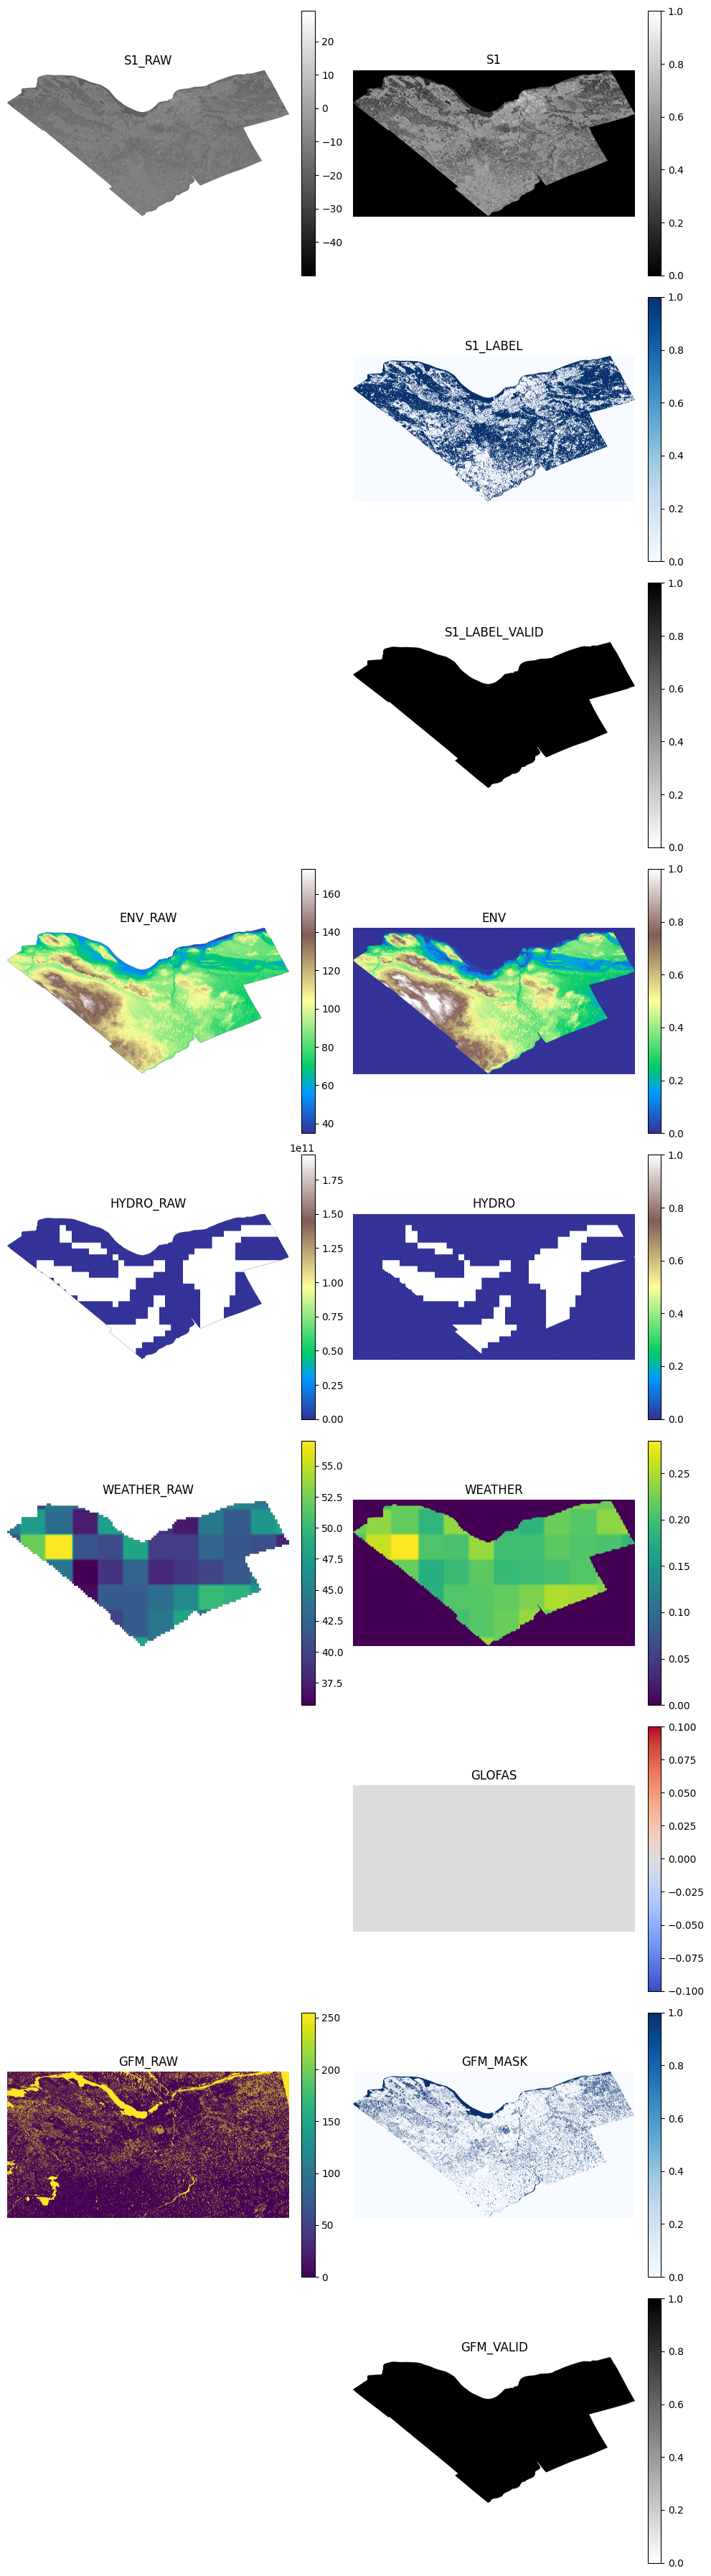

[EXPORT] Saved _Ottawa_2019-04-01.npz and .json


In [36]:
# Run the Pipeline
tensors, tensors_selected_features, master_profile = process_date_pipeline(TARGET_DATE, BASE_DIR, REGION, global_stats)

if tensors is not None:
    # Analyze the math
    analyze_sample(tensors)
    
    # Visualize the arrays
    visualize_pipeline(tensors)
    
    # Save to disk
    export_prepared_sample(tensors, master_profile, EXPORT_DIR, REGION, TARGET_DATE)

### Run All

In [45]:
from src.utils.SystemProfiler import SystemProfiler

In [46]:
REGIONS = ["Ottawa", "Gatineau"] 
ROOT_DIR = r"D:\Projects\datasets\raw"
EXPORT_DIR = r"D:\Projects\datasets\raw\prepared"

### Loop through all

In [ ]:
with SystemProfiler(process_name="Sequential Execution (1 Worker)"):

    for REGION in REGIONS:
        print(f"\n{'='*20} Processing Region: {REGION} {'='*20}")
        
        # Dynamically set the BASE_DIR for the current region
        BASE_DIR = rf"{ROOT_DIR}\{REGION}"

        # Ensure the stats json is unique per region
        stats_file_name = f"stats_{REGION}.json"
        global_stats = calculate_and_save_global_stats(BASE_DIR, stats_file_name)
        
        # Date Inventory
        target_dates = inventory_dataset_dates(BASE_DIR, REGION)
        
        # Initialize the Static Cache
        region_static_cache = None 
        
        # Process all dates
        for target_date in target_dates:
            tensors, selected_tensors, profile = process_date_pipeline(
                target_date, BASE_DIR, REGION, global_stats, static_cache=region_static_cache
            )

            if tensors is not None:
                if region_static_cache is None:
                    region_static_cache = {
                        "env_raw": tensors["env_raw"],
                        "env": tensors["env"],
                        "hydro_raw": tensors["hydro_raw"],
                        "hydro": tensors["hydro"]
                    }
                
                export_prepared_sample(selected_tensors, profile, EXPORT_DIR, REGION, target_date, name_prefix="selected")
                export_prepared_sample(tensors, profile, EXPORT_DIR, REGION, target_date, name_prefix="full")

### Parallelized for efficiency

Slicing through dates - parallelizing such that 1 worker handles 1 date 

In [52]:
import concurrent.futures
import functools

In [53]:
def process_single_date_worker(target_date, base_dir, region, global_stats, static_cache, export_dir):
    try:
        tensors, selected_tensors, profile = process_date_pipeline(
            target_date, base_dir, region, global_stats, static_cache=static_cache
        )
        if tensors is not None:
            export_prepared_sample(selected_tensors, profile, export_dir, region, target_date, name_prefix="selected")
            export_prepared_sample(tensors, profile, export_dir, region, target_date, name_prefix="full")
            return f"[SUCCESS] Finished {region} - {target_date}"
        return f"[SKIPPED] {region} - {target_date} (Missing core data)"
    except Exception as e:
        return f"[FAILED] {region} - {target_date} Error: {str(e)}"

In [54]:
REGIONS = ["Ottawa", "Gatineau"] 
ROOT_DIR = r"D:\Projects\datasets\raw"
EXPORT_DIR = r"D:\Projects\datasets\raw\prepared" 
MAX_WORKERS = 4 

In [55]:
with SystemProfiler(process_name=f"Parallel Execution ({MAX_WORKERS} Workers)"):
    
    for REGION in REGIONS:
        print(f"\n{'='*20} Processing Region: {REGION} {'='*20}")
        BASE_DIR = rf"{ROOT_DIR}\{REGION}"
        
        target_dates = inventory_dataset_dates(BASE_DIR, REGION)
        
        if not target_dates:
            print(f"No dates found for {REGION}. Skipping.")
            continue

        # ---------------------------------------------------------
        # STEP 1: Process the VERY FIRST date sequentially to build the cache
        # ---------------------------------------------------------
        first_date = target_dates[0]
        print(f"\n--- Initializing Cache with first date: {first_date} ---")
        
        tensors, selected_tensors, profile = process_date_pipeline(
            first_date, BASE_DIR, REGION, global_stats, static_cache=None
        )
        
        if tensors is None:
            print(f"CRITICAL ERROR: First date {first_date} failed. Cannot build cache. Skipping region.")
            continue
            
        # Export the first date
        export_prepared_sample(selected_tensors, profile, EXPORT_DIR, REGION, first_date, name_prefix="selected")
        # export_prepared_sample(tensors, profile, EXPORT_DIR, REGION, first_date, name_prefix="full")
        
        # Capture the heavy static math into the cache
        region_static_cache = {
            "env_raw": tensors["env_raw"],
            "env": tensors["env"],
            "hydro_raw": tensors["hydro_raw"],
            "hydro": tensors["hydro"]
        }
        
        # ---------------------------------------------------------
        # STEP 2: Parallelize all remaining dates
        # ---------------------------------------------------------
        remaining_dates = target_dates[1:]
        
        if not remaining_dates:
            continue # Move to next region if there was only 1 date total
            
        print(f"\n--- Spinning up {MAX_WORKERS} parallel workers for remaining {len(remaining_dates)} dates ---")
        
        # 'functools.partial' freezes all the arguments except 'target_date'
        worker = functools.partial(
            process_single_date_worker,
            base_dir=BASE_DIR,
            region=REGION,
            global_stats=global_stats,
            static_cache=region_static_cache,
            export_dir=EXPORT_DIR
        )
        
        # Launch the multiprocessing pool
        with concurrent.futures.ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
            # .map() automatically hands out dates to available CPU cores
            results = executor.map(worker, remaining_dates)
            
            # Print results as they finish
            for result in results:
                print(result)



[PROFILER] Starting Parallel Execution (4 Workers)...

==================== Processing Region: Ottawa ====================
Inventory for Ottawa: Found 10 master (S1) dates.

--- Initializing Cache with first date: 2019-04-01 ---

Executing Pipeline for Target Date: 2019-04-01
Checking s1 path: D:\Projects\datasets\raw\Ottawa\S1\S1_Ottawa_S1_2019-04-01.tif
[OK] S1 cropped to AOI boundary
[OK] S1 Master Grid established: (2, 6399, 12333)
[OK] S1 Labels created (VV thr=-11.45, VH thr=-25.54)
[OK] Static features (ENV, HYDRO) aligned and normalized
Processing weather for 2019-04-01 : D:\Projects\datasets\raw\Ottawa\WEATHER\WEATHER_Ottawa_weather_1km_2019-04-01.tif
[OK] Weather aligned (6 bands)
  [WARN] GloFAS missing for 2019-04-01; returning empty tensor.
Building GFM mosaic for 2019-04-01 : 4 tiles
[OK] GFM reference labels aligned
[EXPORT] Saved selected_Ottawa_2019-04-01.npz and .json

--- Spinning up 4 parallel workers for remaining 9 dates ---

Executing Pipeline for Target Date: 2